<a href="https://colab.research.google.com/github/smichelle0804/26-1-ESAA/blob/main/ESAA_%EB%AF%B8%EB%8B%88%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B83_YB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESAA 미니프로젝트 3_회귀
### YB 1조

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 1. 데이터 불러오기

train = pd.read_csv('/content/drive/MyDrive/datasets/영화 관객수/movies_train.csv')
test = pd.read_csv('/content/drive/MyDrive/datasets/영화 관객수/movies_test.csv')
submission = pd.read_csv('/content/drive/MyDrive/datasets/영화 관객수/submission.csv')

print("train shape:", train.shape)
print("test shape:", test.shape)

train.head()

train shape: (600, 12)
test shape: (243, 11)


,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [ ]:
# 2. 기본 정보 확인

print(train.info())

print("\n[결측치 확인]")
display(train.isnull().sum().sort_values(ascending=False))

print("\n[수치형 변수 요약]")
display(train.describe())

# 장르 한국어 영어로 번역
genre_map = {
    '드라마': 'Drama',
    '코미디': 'Comedy',
    '액션': 'Action',
    '멜로/로맨스': 'Romance',
    '공포': 'Horror',
    '다큐멘터리': 'Documentary',
    '애니메이션': 'Animation',
    '범죄': 'Crime',
    'SF': 'SF',
    '미스터리': 'Mystery',
    '스릴러': 'Thriller',
    '어드벤처': 'Adventure',
    '판타지': 'Fantasy',
    '사극': 'Historical',
    '뮤지컬': 'Musical',
    '서스펜스': 'Suspense'
}

train['genre_eng'] = train['genre'].map(genre_map)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    object 
 1   distributor     600 non-null    object 
 2   genre           600 non-null    object 
 3   release_time    600 non-null    object 
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    object 
 6   director        600 non-null    object 
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.4+ KB
None

[결측치 확인]


,0
dir_prev_bfnum,330
title,0
genre,0
distributor,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_num,0
num_staff,0



[수치형 변수 요약]


,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
count,600.000000,2.700000e+02,600.000000,600.000000,600.000000,6.000000e+02
mean,100.863333,1.050443e+06,0.876667,151.118333,3.706667,7.081818e+05
std,18.097528,1.791408e+06,1.183409,165.654671,2.446889,1.828006e+06
min,45.000000,1.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
25%,89.000000,2.038000e+04,0.000000,17.000000,2.000000,1.297250e+03
50%,100.000000,4.784236e+05,0.000000,82.500000,3.000000,1.259100e+04
75%,114.000000,1.286569e+06,2.000000,264.000000,4.000000,4.798868e+05
max,180.000000,1.761531e+07,5.000000,869.000000,25.000000,1.426277e+07


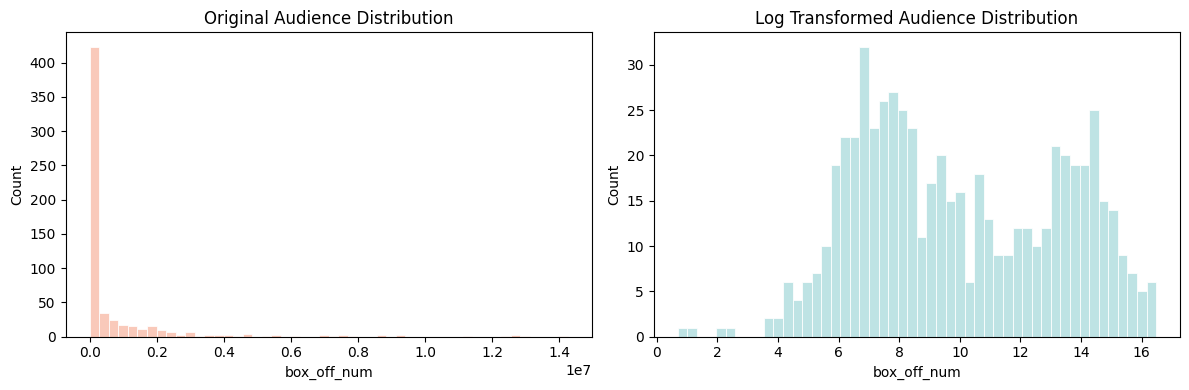

In [ ]:
# 3. 타겟 변수 확인

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(
    train['box_off_num'],
    bins=50,
    color='#F7B7A3',
    edgecolor='white'
)
plt.title('Original Audience Distribution')

plt.subplot(1, 2, 2)
sns.histplot(
    np.log1p(train['box_off_num']),
    bins=50,
    color='#A8DADC',
    edgecolor='white'
)
plt.title('Log Transformed Audience Distribution')

plt.tight_layout()
plt.show()

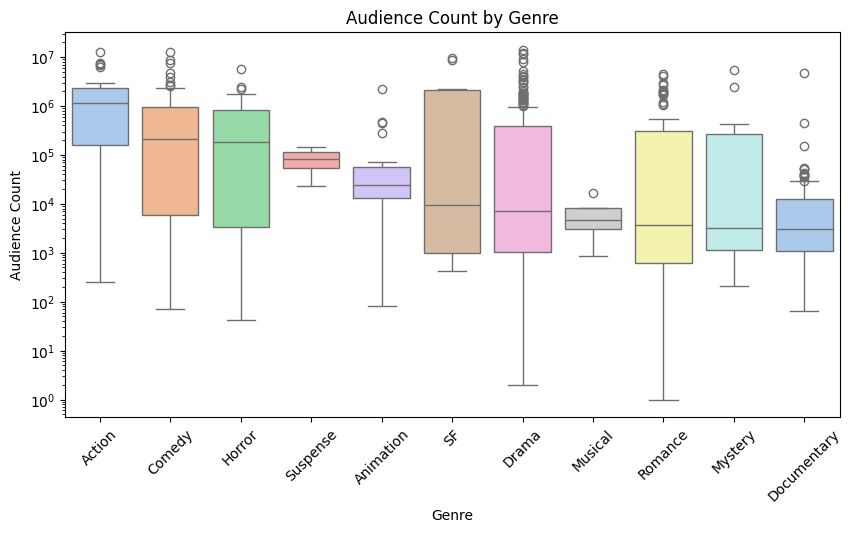

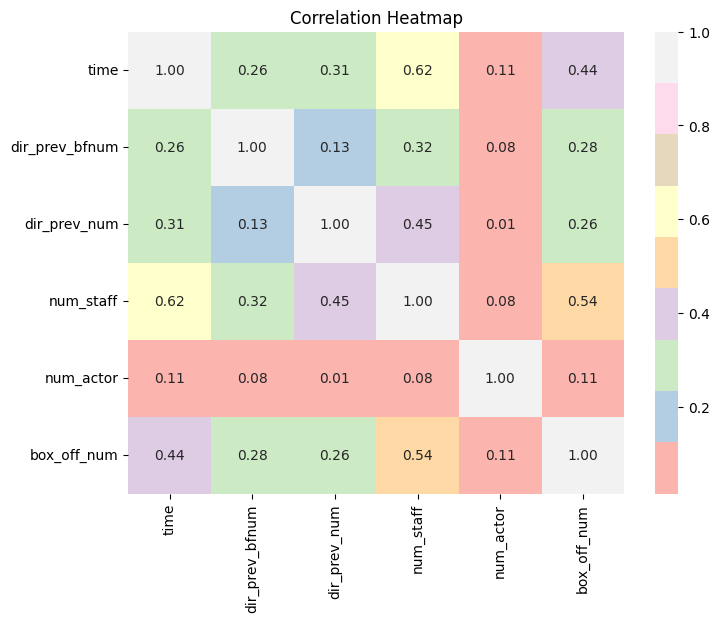

In [ ]:
# 4. EDA

plt.figure(figsize=(10, 5))
genre_order = train.groupby('genre_eng')['box_off_num'].median().sort_values(ascending=False).index

sns.boxplot(
    data=train,
    x='genre_eng',
    y='box_off_num',
    order=genre_order,
    palette='pastel'
)

plt.yscale('log')
plt.xticks(rotation=45)
plt.title('Audience Count by Genre')
plt.xlabel('Genre')
plt.ylabel('Audience Count')
plt.show()


# Correlation between numerical variables and audience count
num_cols = ['time', 'dir_prev_bfnum', 'dir_prev_num',
            'num_staff', 'num_actor', 'box_off_num']

plt.figure(figsize=(8, 6))
sns.heatmap(
    train[num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='Pastel1'
)

plt.title('Correlation Heatmap')
plt.show()


[장르별 관객수 중앙값]


,box_off_num
genre,
느와르,1646142.0
액션,1147846.5
코미디,210775.0
공포,179810.0
서스펜스,82611.0
애니메이션,23802.0
SF,9323.0
드라마,7173.0
뮤지컬,4778.0


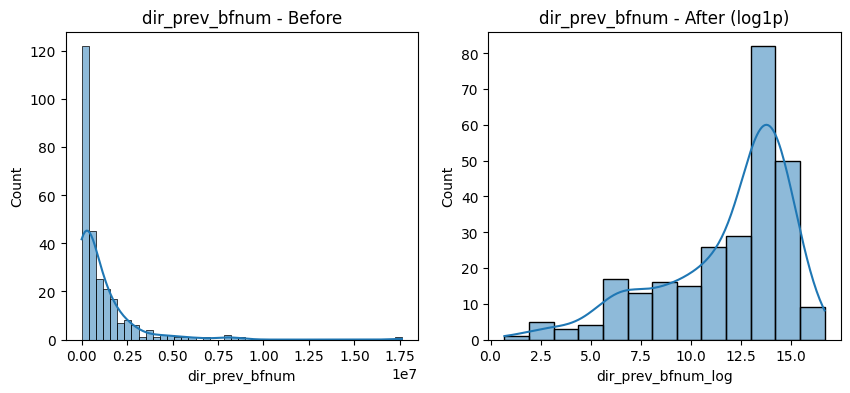

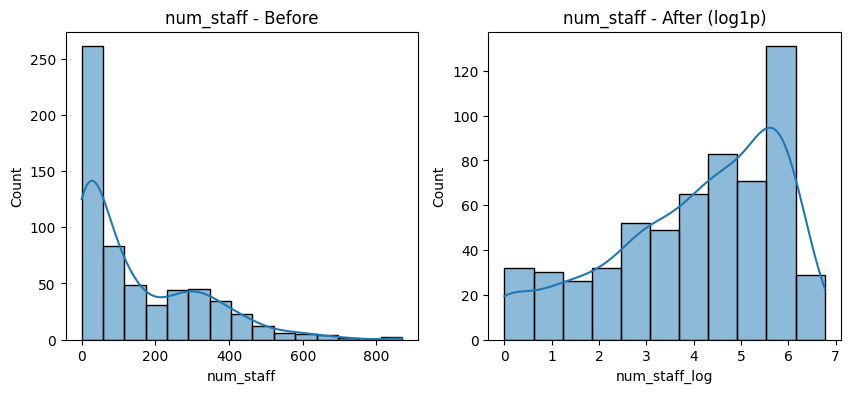

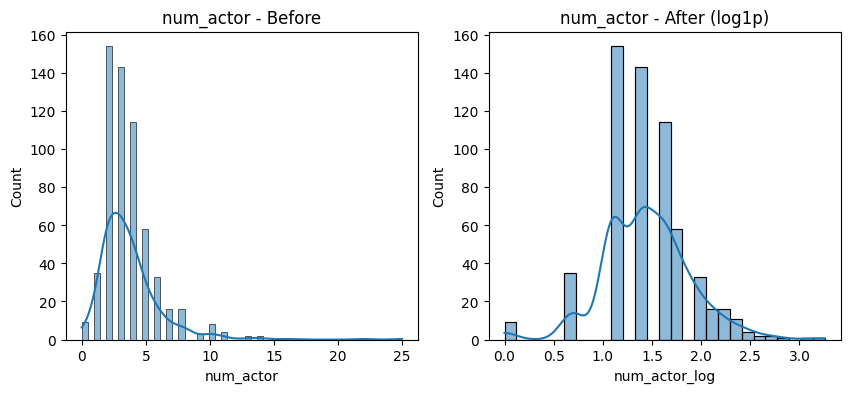

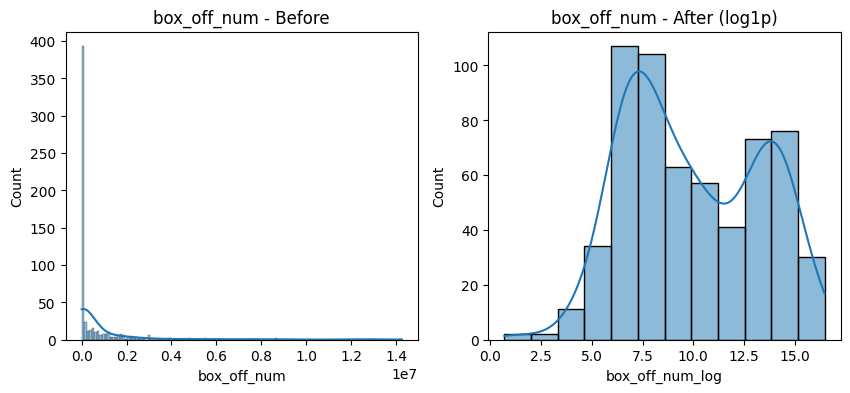

In [ ]:
# 3. 전처리 및 피처 엔지니어링

# 인코딩 일관성을 위해 train / test 합치기
train['is_train'] = 1
test['is_train']  = 0
test['box_off_num'] = 0

data = pd.concat([train, test], ignore_index=True)

# 날짜 변수 처리
data['release_time'] = pd.to_datetime(data['release_time'])

data['release_year'] = data['release_time'].dt.year
data['release_month'] = data['release_time'].dt.month
data['release_day'] = data['release_time'].dt.day
data['release_weekday'] = data['release_time'].dt.weekday

# 주말 개봉 여부
data['weekend_release'] = data['release_weekday'].isin([5, 6]).astype(int)

# 성수기 여부: 여름방학/겨울방학 시즌 중심
data['peak_season'] = data['release_month'].isin([1, 7, 8, 12]).astype(int)

# 배급사 결측 처리
data['distributor'] = data['distributor'].fillna('unknown')

# 배급사별 평균 관객수 feature 생성
dist_mean = train.groupby('distributor')['box_off_num'].mean()
data['distributor_power'] = data['distributor'].map(dist_mean)

# test에만 있는 배급사는 전체 평균으로 대체
data['distributor_power'] = data['distributor_power'].fillna(train['box_off_num'].mean())

# 감독 총 이전 관객수
data['director_total_audience'] = data['dir_prev_bfnum'] * data['dir_prev_num']

# 스태프 1명당 배우 수 비율
data['actor_staff_ratio'] = data['num_actor'] / (data['num_staff'] + 1)

# 범주형 변수 레이블 인코딩 (장르, 상영등급)
le = LabelEncoder()
for col in ['genre', 'screening_rat']:
    data[col] = le.fit_transform(data[col])

# 영화 길이 구간화
data['time_group'] = pd.cut(
    data['time'],
    bins=[0, 80, 100, 120, 150, 300],
    labels=['short', 'normal', 'long', 'very_long', 'extra_long']
)

# feature별 관객수 시각화, 로그변환
transform_cols_train = ['dir_prev_bfnum', 'num_staff', 'num_actor', 'box_off_num']

for col in transform_cols_train:
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    sns.histplot(train[col], ax=ax[0], kde=True)
    ax[0].set_title(f"{col} - Before")

    train[col + "_log"] = np.log1p(train[col])

    sns.histplot(train[col + "_log"], ax=ax[1], kde=True)
    ax[1].set_title(f"{col} - After (log1p)")

transform_cols_test = ['dir_prev_bfnum', 'num_staff', 'num_actor']

for col in transform_cols_test:
    test[col + "_log"] = np.log1p(test[col])

# 장르별 관객수 중앙값 확인용
genre_median = train.groupby('genre')['box_off_num'].median().sort_values(ascending=False)
print("\n[장르별 관객수 중앙값]")
display(genre_median)


In [ ]:

# 4. 인코딩

cat_cols = ['distributor', 'genre', 'screening_rat', 'time_group']

for col in cat_cols:
    le = LabelEncoder()
    data[col] = data[col].astype(str)
    data[col] = le.fit_transform(data[col])

#모델에 불필요한 컬럼 제거
drop_cols = ['title', 'distributor', 'director', 'release_time', 'genre_eng']
data.drop(columns=drop_cols, inplace=True, errors='ignore')

# 남아있는 결측치 처리
data = data.fillna(0)

feature_cols = [c for c in data.columns
                if c not in ['box_off_num', 'is_train']]
print("[Feature List]")
print(feature_cols)

# train / test 다시 분리
train_df = data[data['is_train'] == 1].drop(columns=['is_train'])
test_df  = data[data['is_train'] == 0].drop(columns=['is_train'])

X = train_df[feature_cols]
y = np.log1p(train_df['box_off_num'])
X_test = test_df[feature_cols]

# 8:2 비율로 분리
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"\nTrain: {X_train.shape}  |  Val: {X_valid.shape}  |  Test: {X_test.shape}")

[Feature List]
['genre', 'time', 'screening_rat', 'dir_prev_bfnum', 'dir_prev_num', 'num_staff', 'num_actor', 'release_year', 'release_month', 'release_day', 'release_weekday', 'weekend_release', 'peak_season', 'distributor_power', 'director_total_audience', 'actor_staff_ratio', 'time_group']

Train: (480, 17)  |  Val: (120, 17)  |  Test: (243, 17)


In [ ]:
# 5. 회귀 모델 정의

models = {
    'Ridge Regression': Ridge(alpha=1.0),

    'Random Forest': RandomForestRegressor(
        n_estimators=400,
        max_depth=10,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
    )
}

In [ ]:
results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n========== {name} ==========")

    # Cross Validation
    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring='neg_mean_absolute_error'
    )

    cv_mae_log = -cv_scores.mean()

    # Validation 성능
    model.fit(X_train, y_train)

    valid_pred_log = model.predict(X_valid)

    valid_pred = np.expm1(valid_pred_log)
    valid_true = np.expm1(y_valid)

    valid_pred = np.maximum(valid_pred, 0)

    valid_mae = mean_absolute_error(valid_true, valid_pred)

    results[name] = {
        'model': model,
        'cv_mae_log': cv_mae_log,
        'valid_mae': valid_mae
    }

    print(f"5-Fold CV MAE log scale : {cv_mae_log:.4f}")
    print(f"Validation MAE original : {valid_mae:,.0f}")



========== Ridge Regression ==========
5-Fold CV MAE log scale : 1.5268
Validation MAE original : 568,121

========== Random Forest ==========
5-Fold CV MAE log scale : 1.1429
Validation MAE original : 513,908

========== XGBoost ==========
5-Fold CV MAE log scale : 1.1623
Validation MAE original : 566,661


,Model,Validation MAE
1,Random Forest,513907.831463
2,XGBoost,566661.382646
0,Ridge Regression,568121.050712


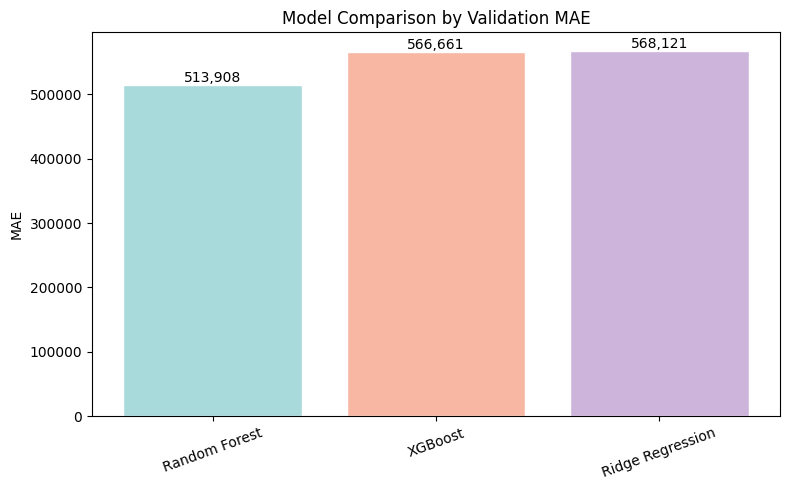


Best Model: Random Forest


In [ ]:
result_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Validation MAE': [results[m]['valid_mae'] for m in results.keys()]
})

result_df = result_df.sort_values('Validation MAE')

display(result_df)

plt.figure(figsize=(8, 5))

pastel_colors = ['#A8DADC', '#F7B7A3', '#CDB4DB']

bars = plt.bar(
    result_df['Model'],
    result_df['Validation MAE'],
    color=pastel_colors,
    edgecolor='white'
)

plt.title('Model Comparison by Validation MAE')
plt.ylabel('MAE')
plt.xticks(rotation=20)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


# 가장 좋은 모델 선택
best_model_name = result_df.iloc[0]['Model']
best_model = results[best_model_name]['model']

print("\nBest Model:", best_model_name)

,feature,importance
13,distributor_power,0.743006
5,num_staff,0.090417
1,time,0.039548
8,release_month,0.024107
15,actor_staff_ratio,0.017091
9,release_day,0.015162
0,genre,0.011460
7,release_year,0.010655
2,screening_rat,0.009717
6,num_actor,0.008271


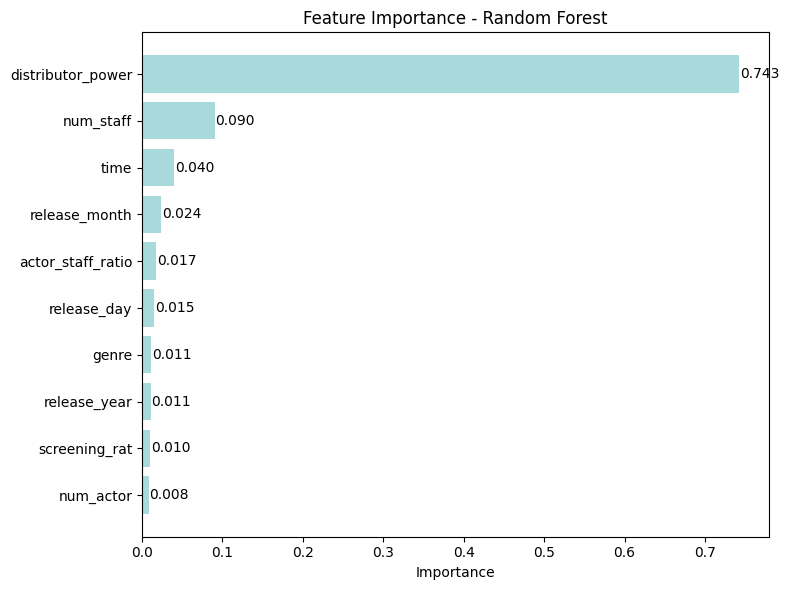

In [ ]:
# 6. 변수 중요도 확인

if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    display(importance_df)

    # 상위 10개 변수만 시각화
    top_importance = importance_df.head(10)

    plt.figure(figsize=(8, 6))

    bars = plt.barh(
        top_importance['feature'],
        top_importance['importance'],
        color='#A8DADC'
    )

    plt.gca().invert_yaxis()
    plt.title(f'Feature Importance - {best_model_name}')
    plt.xlabel('Importance')

    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f'{width:.3f}',
            va='center',
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

In [ ]:
# 7. 전체 train 데이터로 재학습 후 test 예측

best_model.fit(X, y)

test_pred_log = best_model.predict(X_test)
test_pred = np.expm1(test_pred_log)


# 정수형으로 변환
submission['box_off_num'] = test_pred.astype(int)

submission.to_csv('submission_final.csv', index=False)

print("\nSubmission file saved: submission_final.csv")
display(submission.head())

print("\n[Prediction Statistics]")
print("Min :", submission['box_off_num'].min())
print("Max :", submission['box_off_num'].max())
print("Mean:", int(submission['box_off_num'].mean()))


Submission file saved: submission_final.csv


,title,box_off_num
0,용서는 없다,885020
1,아빠가 여자를 좋아해,808385
2,하모니,498215
3,의형제,1424124
4,평행 이론,962247



[Prediction Statistics]
Min : 38
Max : 5150411
Mean: 446846
